#Customer Churn Analysis and Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
#csv hakkında bilgiler
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()
df.shape
df.info()
print(df["Churn"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#eksik veri var mı
print(df.isnull().sum().sum())
#print(df.isnull().sum())

0


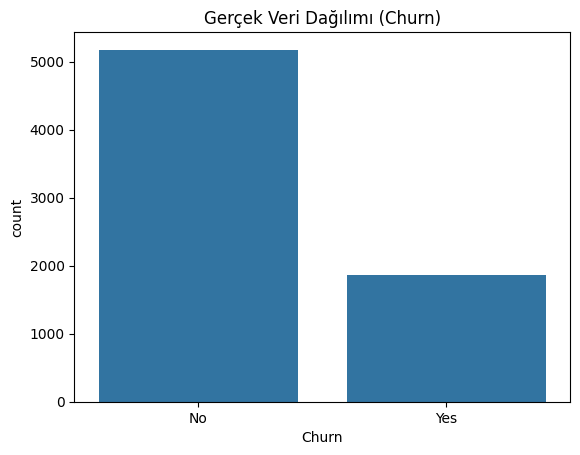

In [6]:
X = df.drop("Churn", axis=1)#churn sütunun at geri kalan X
y = df["Churn"].map({"Yes": 1, "No": 0})
sns.countplot(x="Churn", data=df)
plt.title("Gerçek Veri Dağılımı (Churn)")
plt.show()
X = pd.get_dummies(X, drop_first=True)#dikkat


In [7]:
#scaler aşaması
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LOGISTIC REGRESSION

In [8]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()
logistic.fit(X_train,y_train)
y_pred=logistic.predict(X_test)
print(y_pred)
print(y_pred[:10])

[0 0 0 ... 0 0 0]
[0 0 0 0 0 0 0 0 0 0]


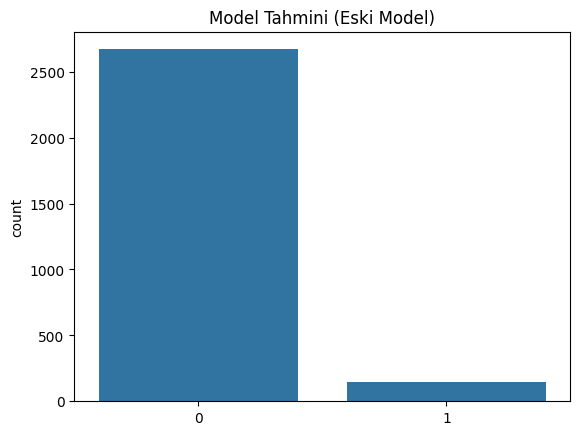

In [9]:
sns.countplot(x=y_pred)
plt.title("Model Tahmini (Eski Model)")
plt.show()

In [10]:
#accuracy_score ne kadar doğru tahmin yaptın
from sklearn.metrics import accuracy_score,confusion_matrix
print("accuracy",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))



accuracy 0.7707594038325053
[[2066   42]
 [ 604  106]]


IMPROVED LOGISTIC REGRESSION

In [11]:
logistic_new = LogisticRegression(max_iter=1000, class_weight="balanced")
logistic_new.fit(X_train, y_train)
y_prob = logistic_new.predict_proba(X_test)[:, 1]
y_pred_new = (y_prob > 0.3).astype(int)

[[1893  215]
 [ 361  349]]
0.7955997161107168
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      2108
           1       0.62      0.49      0.55       710

    accuracy                           0.80      2818
   macro avg       0.73      0.69      0.71      2818
weighted avg       0.78      0.80      0.79      2818



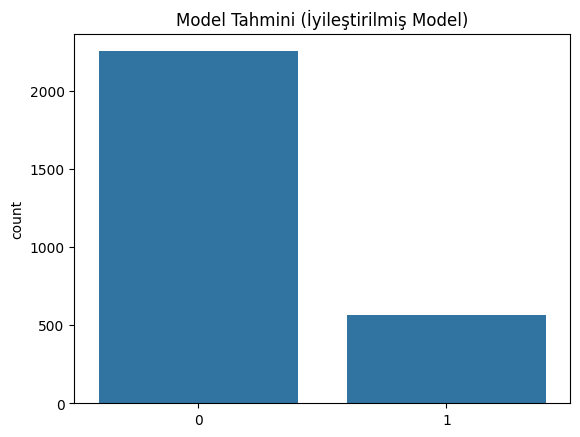

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [12]:
print(confusion_matrix(y_test,y_pred_new))
print(accuracy_score(y_test, y_pred_new))
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_new))
sns.countplot(x=y_pred_new)
plt.title("Model Tahmini (İyileştirilmiş Model)")
plt.show()
plt.figure(figsize=(10,5))

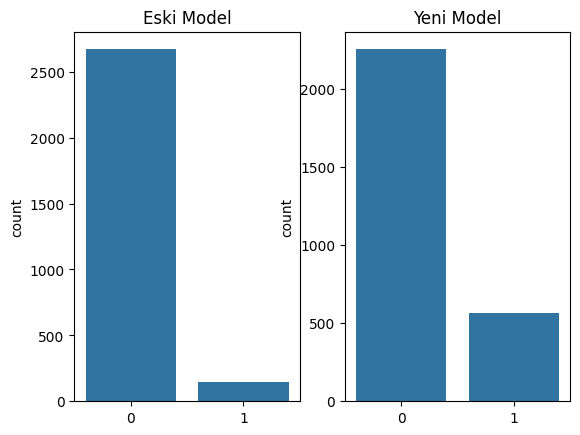

In [13]:
plt.subplot(1,2,1)
sns.countplot(x=y_pred)
plt.title("Eski Model")

plt.subplot(1,2,2)
sns.countplot(x=y_pred_new)
plt.title("Yeni Model")
plt.show()

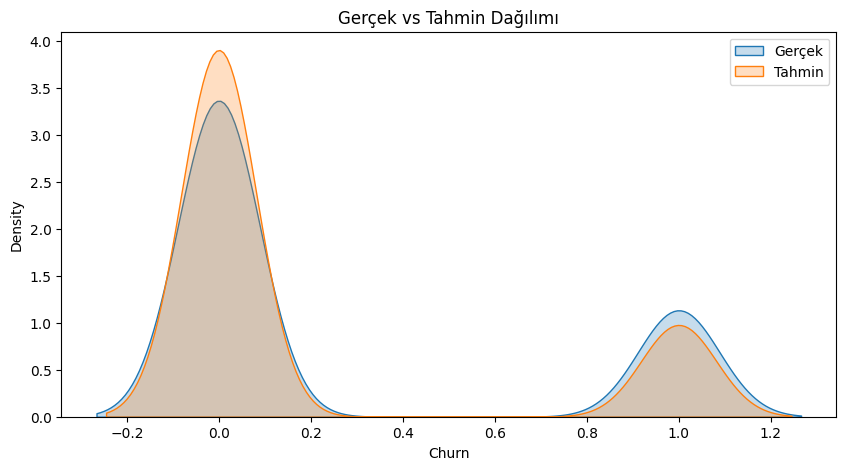

In [14]:
plt.figure(figsize=(10,5))

sns.kdeplot(y_test, label="Gerçek", fill=True)
sns.kdeplot(y_pred_new, label="Tahmin", fill=True)

plt.legend()
plt.title("Gerçek vs Tahmin Dağılımı")
plt.show()

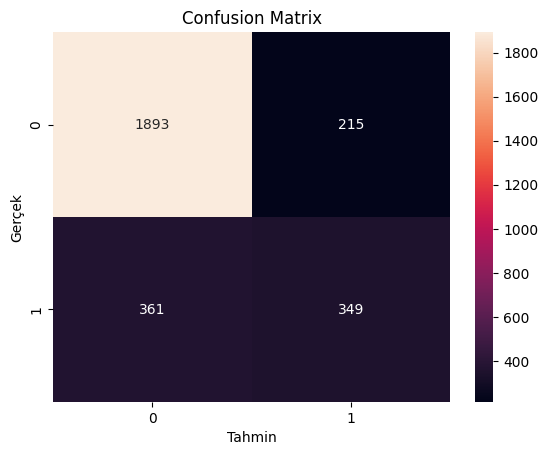

In [15]:
cm=confusion_matrix(y_test,y_pred_new)
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()

ROC AND AUC

[3.24208960e-04 1.46506455e-02 6.21179958e-01 ... 4.85355445e-03
 8.36854131e-04 2.21196834e-02]
AUC 0.8176136515487613


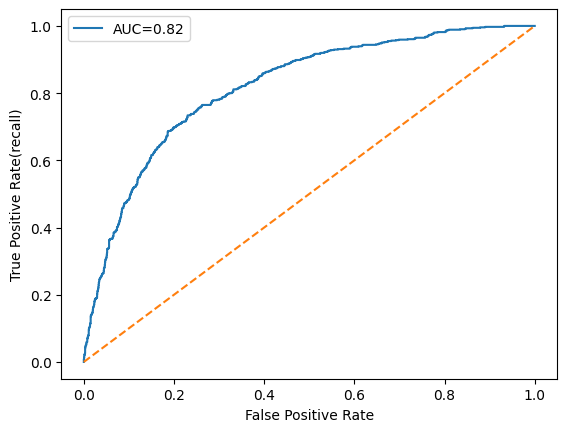

In [16]:
from sklearn.metrics import roc_curve,auc
y_prob=logistic_new.predict_proba(X_test)[:,1]
print(y_prob)
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
roc_auc=auc(fpr,tpr)
print("AUC",roc_auc)
plt.plot(fpr,tpr,label="AUC=%0.2f"%roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate(recall)")
plt.legend()
plt.show()

SUPPORT VECTOR MACHINE

In [17]:
from sklearn.svm import LinearSVC
#svm=SVC( kernel="linear",probability=True) çok yavaş çalışıyor
svm = LinearSVC(max_iter=10000)
svm.fit(X_train, y_train)
svm.fit(X_train,y_train)
y_pred_svm=svm.predict(X_test)
print(y_pred_svm[:10])

[0 0 1 0 0 0 0 0 0 0]


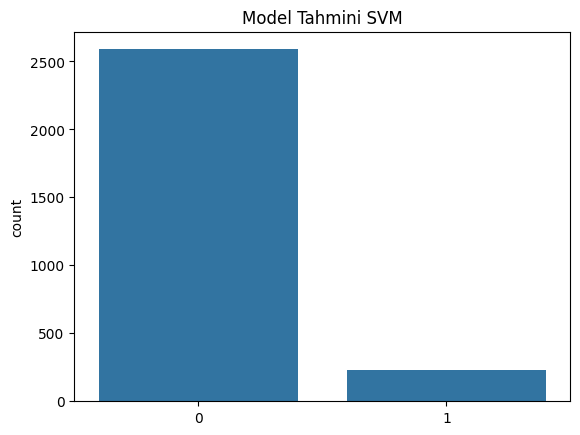

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [19]:
sns.countplot(x=y_pred_svm)
plt.title("Model Tahmini SVM")
plt.show()
plt.figure(figsize=(10,5))

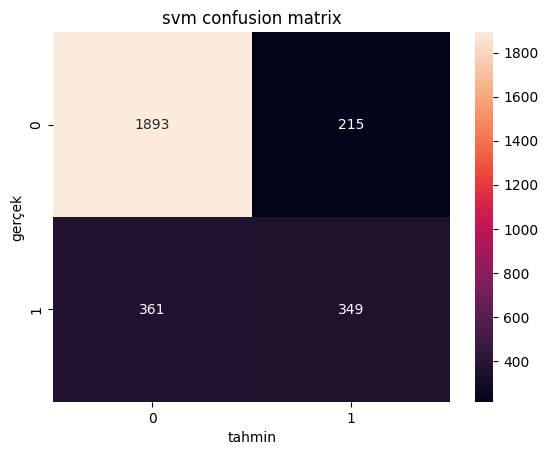

In [18]:
cm_new=confusion_matrix(y_test,y_pred_svm)
sns.heatmap(cm,annot=True,fmt="d")
plt.title("svm confusion matrix")
plt.xlabel("tahmin")
plt.ylabel("gerçek")
plt.show()
